In [ ]:
Домашняя работа 3

problem 1

In [4]:
import numpy as np
from scipy import stats


def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = [rng() for _ in range(1000)]


def serial_test(data, k=10):
    data = np.array(data)
    n = len(data)
    if n % 2 != 0:
        data = data[:-1]
        print("последний элемент отброшен")

    n_pairs = len(data) // 2
    pairs = data[:2*n_pairs].reshape(-1, 2)
    hist, x_edges, y_edges = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=k, range=[[0, 1], [0, 1]])
    observed = hist.flatten()
    expected_count = n_pairs / (k * k)
    expected = np.full_like(observed, expected_count, dtype=float)
    chi2_stat, p_value = stats.chisquare(observed, expected)
    dof = k * k - 1
    return chi2_stat, p_value, dof

chi2_stat, p_value, dof = serial_test(samples, k=10)

print(f"Статистика хи-квадрат: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Степени свободы: {dof}")

if p_value > 0.05:
    print("Вывод: p-value > 0.05, гипотеза не отвергается.")
else:
    print("Вывод: p-value <= 0.05, гипотеза отвергается.")

Статистика хи-квадрат: 114.4000
p-value: 0.1380
Степени свободы: 99
Вывод: p-value > 0.05, гипотеза не отвергается.


problem 3

In [9]:
import numpy as np
from scipy import stats
from itertools import permutations

def rng_good(seed=1):
    state = seed
    def gen():
        nonlocal state
        state = (1103515245 * state + 12345) % 2**32
        return state / 2**32
    return gen

def rng_bad(seed=1):
    state = seed
    def gen():
        nonlocal state
        state = (65539 * state) % 2**31
        return state / 2**31
    return gen

def serial_test(gen, n_pairs=15000, k=16):
    seq = [gen() for _ in range(n_pairs * 2)]
    pairs = [(seq[i], seq[i+1]) for i in range(0, len(seq), 2)]
    observed, _, _ = np.histogram2d([p[0] for p in pairs], [p[1] for p in pairs], bins=k, range=[[0,1],[0,1]])
    expected = np.full_like(observed, n_pairs / (k*k))
    return stats.chisquare(observed.ravel(), f_exp=expected.ravel())

def permutation_test(gen, n_seq=2000, d=4):
    seq = [gen() for _ in range(n_seq * d)]
    subsequences = [seq[i:i+d] for i in range(0, len(seq), d)]
    perms = list(permutations(range(d)))
    n_perms = len(perms)
    perm_to_idx = {perm: i for i, perm in enumerate(perms)}
    observed = np.zeros(n_perms, dtype=int)
    for sub in subsequences:
        observed[perm_to_idx[tuple(np.argsort(sub))]] += 1
    expected = np.full(n_perms, n_seq / n_perms)
    return stats.chisquare(observed, f_exp=expected)

print("1. SERIAL TEST")
gen1 = rng_good(42)
gen2 = rng_bad(42)
_, p1 = serial_test(gen1)
_, p2 = serial_test(gen2)
print(f"rng_good: p = {p1:.6f} -> {'OK' if p1 > 0.05 else 'FAIL'}")
print(f"rng_bad:  p = {p2:.6f} -> {'OK' if p2 > 0.05 else 'FAIL'}")

print("\n2. PERMUTATION TEST")
gen1 = rng_good(42)
gen2 = rng_bad(42)
_, p1 = permutation_test(gen1)
_, p2 = permutation_test(gen2)
print(f"rng_good: p = {p1:.6f} -> {'OK' if p1 > 0.05 else 'FAIL'}")
print(f"rng_bad:  p = {p2:.6f} -> {'OK' if p2 > 0.05 else 'FAIL'}")

1. SERIAL TEST
rng_good: p = 0.429075 -> OK
rng_bad:  p = 0.002951 -> FAIL

2. PERMUTATION TEST
rng_good: p = 0.349049 -> OK
rng_bad:  p = 0.061107 -> OK


problem 4

Исходные веса (не нормированы): [0.12  0.3   0.167 0.24  0.31  0.54  0.111 0.02  0.001 0.2  ]
Сумма исходных весов: 2.009
Нормированные вероятности: [0.05973121 0.14932802 0.08312593 0.11946242 0.15430562 0.26879044
 0.05525137 0.0099552  0.00049776 0.09955202]
Сумма нормированных вероятностей: 1.0
Кумулятивная функция распределения (CDF): [0.05973121 0.20905923 0.29218517 0.41164759 0.56595321 0.83474365
 0.88999502 0.89995022 0.90044798 1.        ]


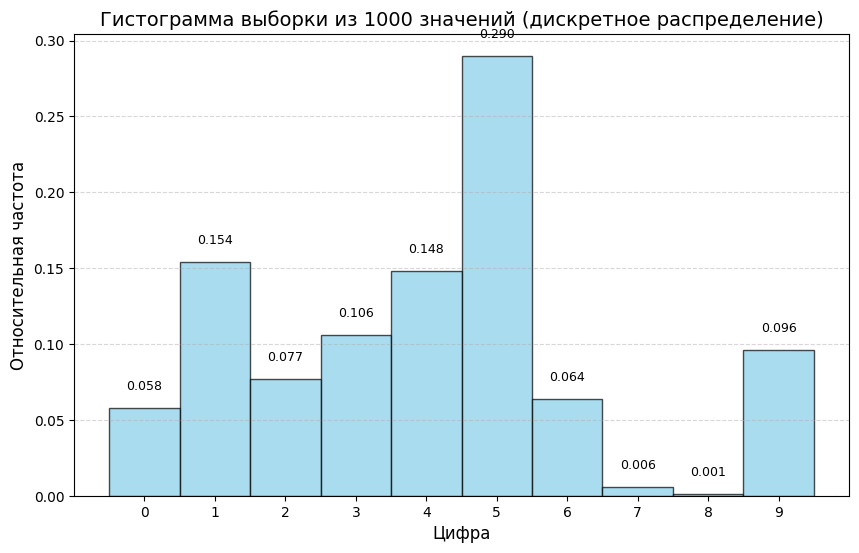

Цифра, Теоретическая P, Эмпирическая P, Разница
  0, 0.0597, 0.0580, 0.0017
  1, 0.1493, 0.1540, 0.0047
  2, 0.0831, 0.0770, 0.0061
  3, 0.1195, 0.1060, 0.0135
  4, 0.1543, 0.1480, 0.0063
  5, 0.2688, 0.2900, 0.0212
  6, 0.0553, 0.0640, 0.0087
  7, 0.0100, 0.0060, 0.0040
  8, 0.0005, 0.0010, 0.0005
  9, 0.0996, 0.0960, 0.0036
Сумма исходных весов: 2.009
Сумма нормированных вероятностей: 1.0
Среднее значение выборки: 3.966
Медиана выборки: 4.0
Минимальное значение в выборке: 0
Максимальное значение в выборке: 9


In [11]:
import numpy as np
import matplotlib.pyplot as plt

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
digits = np.arange(10)
print("Исходные веса (не нормированы):", weights)
print("Сумма исходных весов:", np.sum(weights))


probabilities = weights / np.sum(weights)
print("Нормированные вероятности:", probabilities)
print("Сумма нормированных вероятностей:", np.sum(probabilities))
cdf = np.cumsum(probabilities)
print("Кумулятивная функция распределения (CDF):", cdf)
n_samples = 1000
uniform_samples = np.random.rand(n_samples)

samples = []
for u in uniform_samples:
    for idx, cum_prob in enumerate(cdf):
        if u <= cum_prob:
            samples.append(digits[idx])
            break

samples = np.array(samples)

plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(samples, bins=np.arange(-0.5, 10.5, 1),
edgecolor='black', alpha=0.7, density=True, color='skyblue')

plt.xticks(digits)
plt.title("Гистограмма выборки из 1000 значений (дискретное распределение)", fontsize=14)
plt.xlabel("Цифра", fontsize=12)
plt.ylabel("Относительная частота", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, (count, patch) in enumerate(zip(counts, patches)):
    height = patch.get_height()
    plt.text(patch.get_x() + patch.get_width()/2., height + 0.01,
             f'{count:.3f}', ha='center', va='bottom', fontsize=9)

plt.show()

empirical_probs = [np.mean(samples == d) for d in digits]

print("Цифра, Теоретическая P, Эмпирическая P, Разница")
for i in range(10):
    print(f"  {i}, {probabilities[i]:.4f}, {empirical_probs[i]:.4f}, {abs(probabilities[i] - empirical_probs[i]):.4f}")

print("Сумма исходных весов:", np.sum(weights))
print("Сумма нормированных вероятностей:", np.sum(probabilities))
print("Среднее значение выборки:", np.mean(samples))
print("Медиана выборки:", np.median(samples))
print("Минимальное значение в выборке:", np.min(samples))
print("Максимальное значение в выборке:", np.max(samples))

problem 5

Сгенерировано 1000 точек
Теоретическое среднее: 0.5000
Эмпирическое среднее: 0.5089
Теоретическая дисперсия: 0.2500
Эмпирическая дисперсия: 0.2986


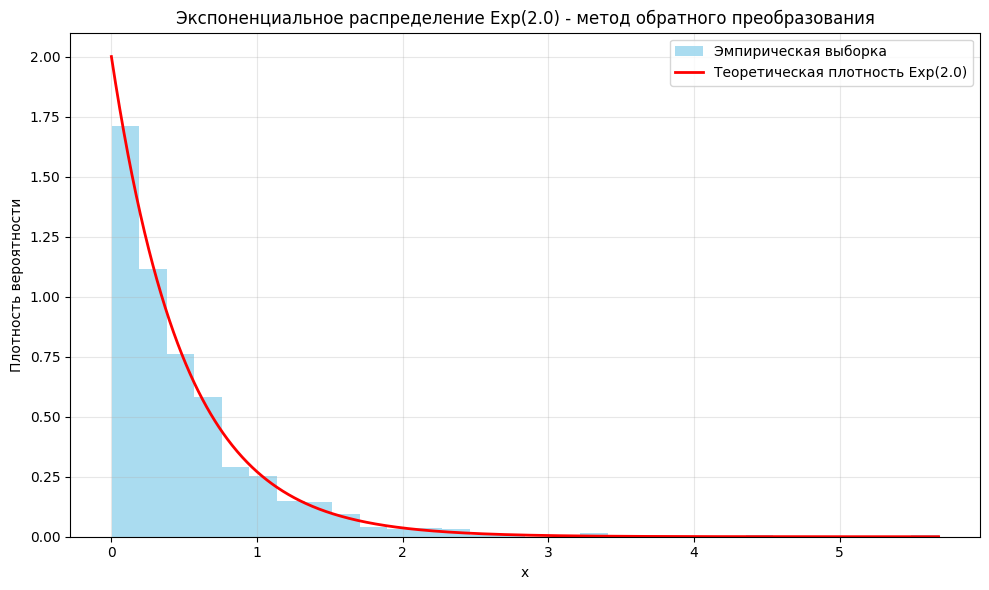


Тест Колмогорова-Смирнова:
KS-статистика: 0.0162
p-value: 0.9505
гипотеза не отвергается


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

lambda_param = 2.0
n_samples = 1000
u = np.random.uniform(0, 1, n_samples)
x = -np.log(u) / lambda_param
plt.figure(figsize=(10, 6))
count, bins, patches = plt.hist(x, bins=30, density=True, alpha=0.7, label='Эмпирическая выборка', color='skyblue')

x_theor = np.linspace(0, np.max(x), 1000)
pdf_theor = lambda_param * np.exp(-lambda_param * x_theor)
plt.plot(x_theor, pdf_theor, 'r-', linewidth=2, label=f'Теоретическая плотность Exp({lambda_param})')

plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.title(f'Экспоненциальное распределение Exp({lambda_param}) - метод обратного преобразования')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Сгенерировано {n_samples} точек")
print(f"Теоретическое среднее: {1/lambda_param:.4f}")
print(f"Эмпирическое среднее: {np.mean(x):.4f}")
print(f"Теоретическая дисперсия: {1/(lambda_param**2):.4f}")
print(f"Эмпирическая дисперсия: {np.var(x):.4f}")

plt.tight_layout()
plt.show()

ks_statistic, p_value = stats.kstest(x, 'expon', args=(0, 1/lambda_param))
print(f"\nТест Колмогорова-Смирнова:")
print(f"KS-статистика: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value > 0.05:
    print("гипотеза не отвергается")
else:
    print("Гипотеза отвергается")

problem 6

Максимальное значение целевой функции: 1.2719
Константа M (для равномерного кандидата): 3.9958
Эффективность метода: 0.4677 (46.8%)
Нормализующая константа: 1.8410


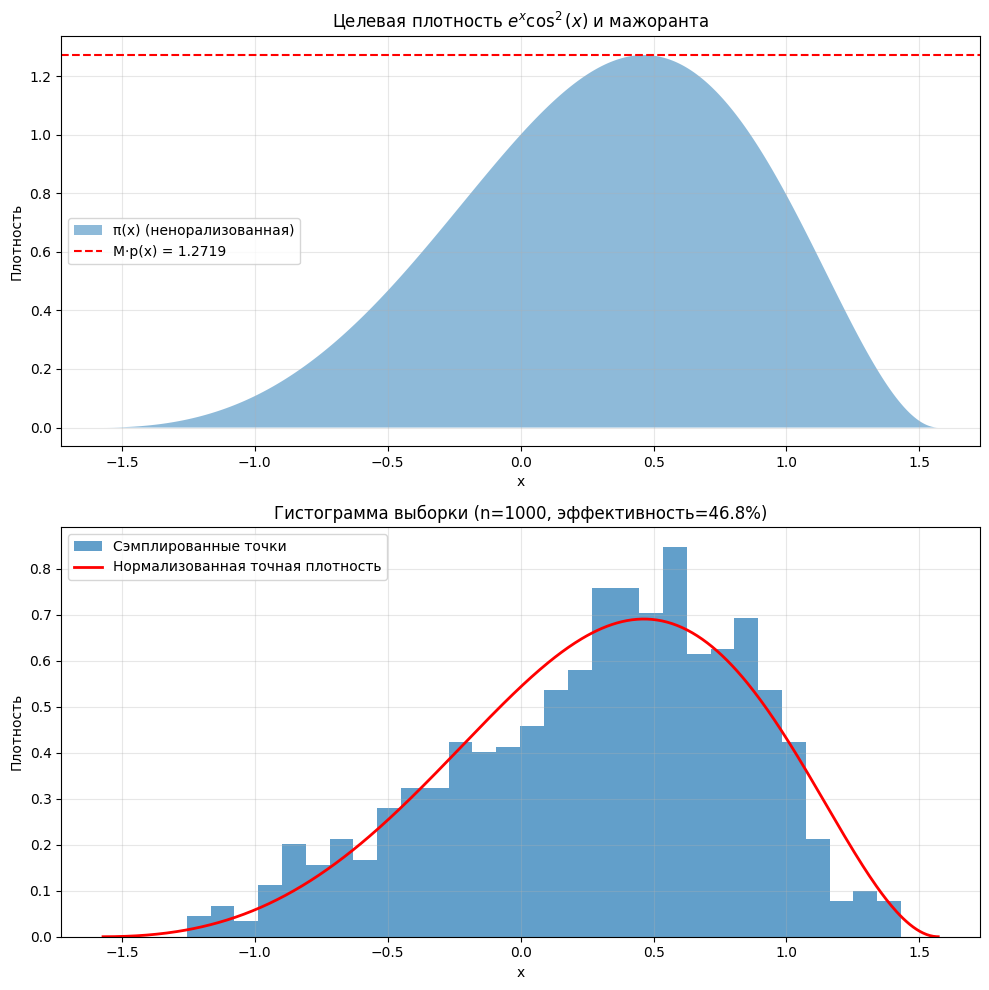


Тест Колмогорова-Смирнова:
  Статистика KS: 0.034781
  p-значение: 0.173731
  Результат: Нет оснований отвергнуть гипотезу о соответствии распределению


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy import stats

def target_pdf(x):
    return np.exp(x) * np.cos(x)**2

a, b = -np.pi/2, np.pi/2

x_vals = np.linspace(a, b, 1000)
target_vals = target_pdf(x_vals)
M = max(target_vals)
M = M * (b - a)

print(f"Максимальное значение целевой функции: {max(target_vals):.4f}")
print(f"Константа M (для равномерного кандидата): {M:.4f}")

def accept_reject_sample(n_samples):
    samples = []
    n_attempts = 0

    while len(samples) < n_samples:
        n_attempts += 1
        x = np.random.uniform(a, b)
        y = np.random.uniform(0, M / (b - a))

        if y <= target_pdf(x):
            samples.append(x)

    efficiency = n_samples / n_attempts
    return np.array(samples), efficiency

np.random.seed(42)
samples, efficiency = accept_reject_sample(1000)

print(f"Эффективность метода: {efficiency:.4f} ({efficiency*100:.1f}%)")

def integrand(x):
    return target_pdf(x)

norm_const, _ = integrate.quad(integrand, a, b)
print(f"Нормализующая константа: {norm_const:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

x_plot = np.linspace(a, b, 500)
ax1.fill_between(x_plot, 0, target_pdf(x_plot), alpha=0.5, label='π(x) (ненорализованная)')
ax1.axhline(y=M/(b-a), color='r', linestyle='--', label=f'M·p(x) = {M/(b-a):.4f}')
ax1.set_xlabel('x')
ax1.set_ylabel('Плотность')
ax1.set_title(r'Целевая плотность $e^x \cos^2(x)$ и мажоранта')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(samples, bins=30, density=True, alpha=0.7, label='Сэмплированные точки')
ax2.plot(x_plot, target_pdf(x_plot) / norm_const, 'r-', linewidth=2, label='Нормализованная точная плотность')
ax2.set_xlabel('x')
ax2.set_ylabel('Плотность')
ax2.set_title(f'Гистограмма выборки (n={len(samples)}, эффективность={efficiency*100:.1f}%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

def normalized_target_cdf(x):
    if np.isscalar(x):
        result, _ = integrate.quad(target_pdf, a, x)
        return result / norm_const
    else:
        return np.array([normalized_target_cdf(xi) for xi in x])

ks_statistic, ks_pvalue = stats.kstest(samples, normalized_target_cdf)
print(f"\nТест Колмогорова-Смирнова:")
print(f"  Статистика KS: {ks_statistic:.6f}")
print(f"  p-значение: {ks_pvalue:.6f}")
if ks_pvalue > 0.05:
    print("  Результат: Нет оснований отвергнуть гипотезу о соответствии распределению")
else:
    print("  Результат: Гипотеза о соответствии распределению отвергается")

problem 7

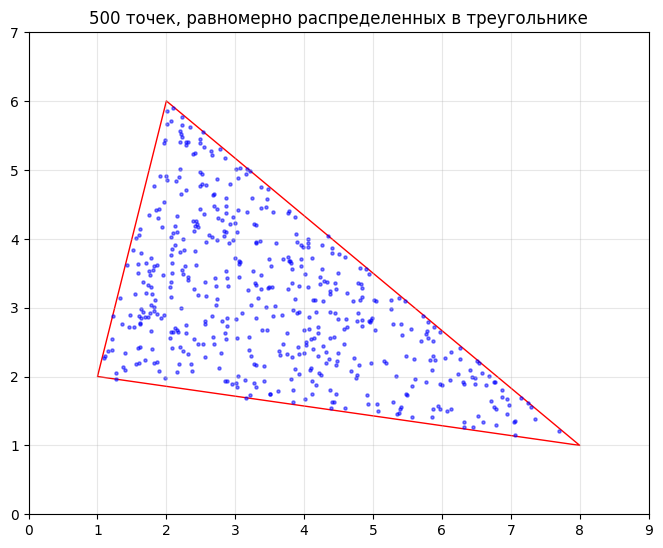

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

n_points = 500

points = []
for _ in range(n_points):
    while True:
        r1, r2 = np.random.rand(2)
        if r1 + r2 < 1:
            u, v = r1, r2
        else:
            u, v = 1 - r1, 1 - r2
        point = A + u * (B - A) + v * (C - A)
        points.append(point)
        break

points = np.array(points)

fig, ax = plt.subplots(figsize=(8, 8))
polygon = Polygon(np.array([A, B, C]), closed=True, edgecolor='red', linewidth=2, fill=None)
ax.add_collection(PatchCollection([polygon], facecolor='none', edgecolor='red'))
ax.scatter(points[:, 0], points[:, 1], s=5, alpha=0.5, color='blue')

ax.set_xlim(0, 9)
ax.set_ylim(0, 7)
ax.set_aspect('equal')
ax.set_title('500 точек, равномерно распределенных в треугольнике')
ax.grid(alpha=0.3)
plt.show()

problem 8

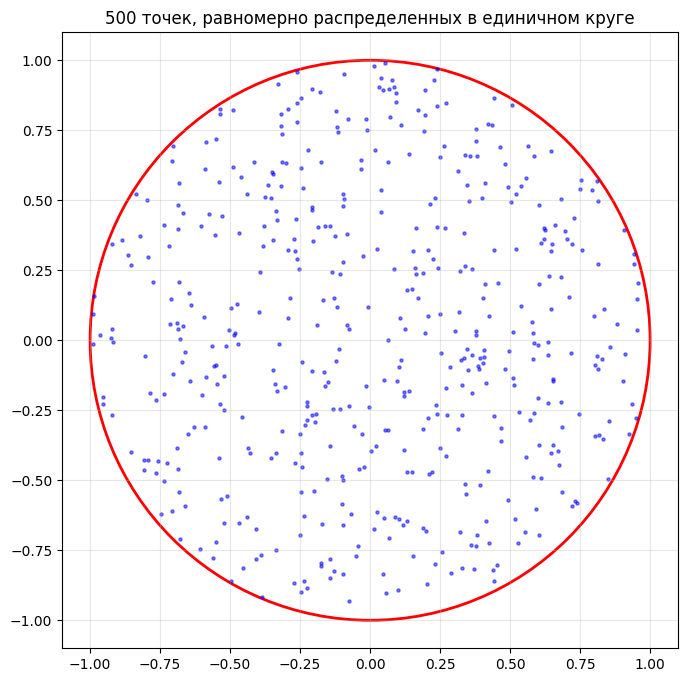

In [15]:
import numpy as np
import matplotlib.pyplot as plt

n_points = 500

u = np.random.rand(n_points, 2)
r = np.sqrt(u[:, 0])
theta = 2 * np.pi * u[:, 1]
x = r * np.cos(theta)
y = r * np.sin(theta)

fig, ax = plt.subplots(figsize=(8, 8))

circle = plt.Circle((0, 0), 1, color='red', fill=False, linewidth=2)
ax.add_patch(circle)
ax.scatter(x, y, s=5, alpha=0.5, color='blue')

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.set_title('500 точек, равномерно распределенных в единичном круге')
ax.grid(alpha=0.3)
plt.show()

problem 9

Теоретическое среднее: [4 7]
Оценка среднего по выборке: [3.84115669 7.42532101]

Теоретическая ковариационная матрица:
 [[20 -4]
 [-4 40]]
Оценка ковариационной матрицы по выборке:
 [[20.28908005 -2.44320605]
 [-2.44320605 38.93575261]]


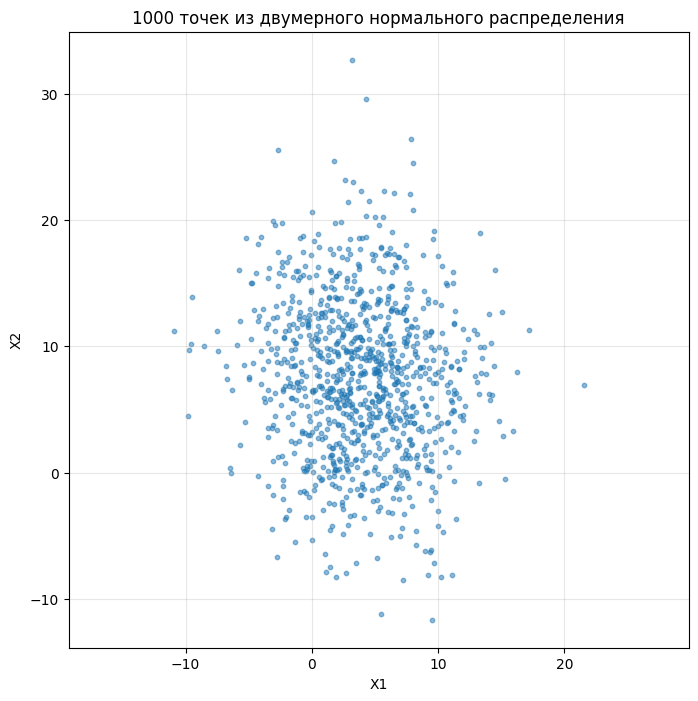

In [16]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])
L = np.linalg.cholesky(Sigma)

def box_muller(n):
    u1 = np.random.rand(n)
    u2 = np.random.rand(n)
    r = np.sqrt(-2 * np.log(u1))
    theta = 2 * np.pi * u2
    z1 = r * np.cos(theta)
    z2 = r * np.sin(theta)
    return np.column_stack((z1, z2))

n_samples = 1000
z = box_muller(n_samples)  # z ~ N(0, I)
x = mu + z @ L.T

estimated_mu = np.mean(x, axis=0)
estimated_cov = np.cov(x, rowvar=False)

print("Теоретическое среднее:", mu)
print("Оценка среднего по выборке:", estimated_mu)
print("\nТеоретическая ковариационная матрица:\n", Sigma)
print("Оценка ковариационной матрицы по выборке:\n", estimated_cov)

plt.figure(figsize=(8, 8))
plt.scatter(x[:, 0], x[:, 1], alpha=0.5, s=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('1000 точек из двумерного нормального распределения')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()